In [1]:
import pandas as pd

train_df=pd.read_csv("/kaggle/input/datasets/ashery/chexpert/train.csv")

print(train_df.head())
print(train_df.shape)

                                                Path     Sex  Age  \
0  CheXpert-v1.0-small/train/patient00001/study1/...  Female   68   
1  CheXpert-v1.0-small/train/patient00002/study2/...  Female   87   
2  CheXpert-v1.0-small/train/patient00002/study1/...  Female   83   
3  CheXpert-v1.0-small/train/patient00002/study1/...  Female   83   
4  CheXpert-v1.0-small/train/patient00003/study1/...    Male   41   

  Frontal/Lateral AP/PA  No Finding  Enlarged Cardiomediastinum  Cardiomegaly  \
0         Frontal    AP         1.0                         NaN           NaN   
1         Frontal    AP         NaN                         NaN          -1.0   
2         Frontal    AP         NaN                         NaN           NaN   
3         Lateral   NaN         NaN                         NaN           NaN   
4         Frontal    AP         NaN                         NaN           NaN   

   Lung Opacity  Lung Lesion  Edema  Consolidation  Pneumonia  Atelectasis  \
0           NaN     

In [2]:
import pandas as pd
import numpy as np

df=pd.read_csv("/kaggle/input/datasets/ashery/chexpert/train.csv")

disease_cols=[
    'No Finding',
    'Enlarged Cardiomediastinum',
    'Cardiomegaly',
    'Lung Opacity',
    'Lung Lesion',
    'Edema',
    'Consolidation',
    'Pneumonia',
    'Atelectasis',
    'Pneumothorax',
    'Pleural Effusion',
    'Pleural Other',
    'Fracture',
    'Support Devices'
]

df[disease_cols]=df[disease_cols].replace(-1,0)
df[disease_cols]=df[disease_cols].fillna(0)

N=300

balanced_indices=set()

for disease in disease_cols:
    positive_indices=df[df[disease]==1].index.tolist()

    sampled=np.random.choice(
        positive_indices,
        size=min(N,len(positive_indices)),
        replace=False
    )

    balanced_indices.update(sampled)

df_balanced=df.loc[list(balanced_indices)].reset_index(drop=True)

print("Balanced subset size:",len(df_balanced))

print(df_balanced[disease_cols].sum().sort_values(ascending=False))

Balanced subset size: 4176
Support Devices               2218.0
Lung Opacity                  2143.0
Pleural Effusion              1673.0
Edema                         1053.0
Atelectasis                    804.0
Cardiomegaly                   700.0
Consolidation                  549.0
Pneumothorax                   534.0
Enlarged Cardiomediastinum     475.0
Fracture                       457.0
Lung Lesion                    450.0
Pneumonia                      389.0
Pleural Other                  352.0
No Finding                     324.0
dtype: float64


In [3]:
import pandas as pd
import numpy as np

df=pd.read_csv("/kaggle/input/datasets/ashery/chexpert/train.csv")

disease_cols=[
    "Cardiomegaly",
    "Edema",
    "Pleural Effusion"
]

df[disease_cols]=df[disease_cols].replace(-1,0)
df[disease_cols]=df[disease_cols].fillna(0)

N=1000

selected_indices=set()

for disease in disease_cols:

    positive_indices=df[df[disease]==1].index.tolist()

    sampled=np.random.choice(
        positive_indices,
        size=min(N,len(positive_indices)),
        replace=False
    )

    selected_indices.update(sampled)

df_balanced=df.loc[list(selected_indices)].reset_index(drop=True)

print("Dataset size:",len(df_balanced))

print(df_balanced[disease_cols].sum())

Dataset size: 2976
Cardiomegaly        1335.0
Edema               1717.0
Pleural Effusion    1906.0
dtype: float64


In [4]:
BASE_PATH="/kaggle/input/datasets/ashery/chexpert/"

df_balanced["full_path"]=df_balanced["Path"].str.replace(
    "CheXpert-v1.0-small/",
    BASE_PATH,
    regex=False
)

print(df_balanced["full_path"].head())

0    /kaggle/input/datasets/ashery/chexpert/train/p...
1    /kaggle/input/datasets/ashery/chexpert/train/p...
2    /kaggle/input/datasets/ashery/chexpert/train/p...
3    /kaggle/input/datasets/ashery/chexpert/train/p...
4    /kaggle/input/datasets/ashery/chexpert/train/p...
Name: full_path, dtype: object


In [5]:
from sklearn.model_selection import train_test_split

train_df,val_df=train_test_split(
    df_balanced,
    test_size=0.2,
    random_state=42
)

print("Train:",len(train_df))
print("Validation:",len(val_df))

Train: 2380
Validation: 596


In [6]:
from torchvision import transforms

train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [7]:
import torch
from torch.utils.data import Dataset
from PIL import Image

disease_cols=[
    "Cardiomegaly",
    "Edema",
    "Pleural Effusion"
]

class CheXpertDataset(Dataset):

    def __init__(self,df,transform=None):
        self.df=df
        self.transform=transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self,idx):

        img_path=self.df.iloc[idx]["full_path"]

        image=Image.open(img_path).convert("RGB")

        labels=torch.tensor(
            self.df.iloc[idx][disease_cols].values.astype("float32")
        )

        if self.transform:
            image=self.transform(image)

        return image,labels

In [8]:
from torch.utils.data import DataLoader

train_dataset=CheXpertDataset(
    train_df,
    transform=train_transform
)

val_dataset=CheXpertDataset(
    val_df,
    transform=val_transform
)

train_loader=DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader=DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

print(len(train_loader))
print(len(val_loader))

149
38


In [9]:
images,labels=next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([16, 3, 224, 224])
torch.Size([16, 3])


In [10]:
import torch
import torch.nn as nn
from torchvision import models

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=models.densenet121(pretrained=True)

num_features=model.classifier.in_features

model.classifier=nn.Linear(
    num_features,
    len(disease_cols)
)

model=model.to(device)

criterion=nn.BCEWithLogitsLoss()

optimizer=torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 127MB/s]


cuda


In [11]:
images,labels=next(iter(train_loader))

images=images.to(device)
labels=labels.to(device)

outputs=model(images)

print(outputs.shape)

torch.Size([16, 3])


In [12]:
model.eval()

images,labels=next(iter(val_loader))

images=images.to(device)

with torch.no_grad():
    outputs=model(images)

preds=torch.sigmoid(outputs)

print(preds[:5])

tensor([[0.4184, 0.8531, 0.1687],
        [0.4279, 0.7679, 0.3288],
        [0.3732, 0.7007, 0.2735],
        [0.4798, 0.7464, 0.2925],
        [0.4034, 0.8129, 0.1674]], device='cuda:0')


In [13]:
predictions=(preds>0.5).float()

print(predictions[:5])
print(labels[:5])

tensor([[0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.]], device='cuda:0')
tensor([[1., 1., 0.],
        [1., 0., 1.],
        [1., 0., 1.],
        [0., 0., 1.],
        [0., 1., 1.]])


In [14]:
correct=0
total=0

disease_correct=[0,0,0]
disease_total=[0,0,0]

model.eval()

with torch.no_grad():

    for images,labels in val_loader:

        images=images.to(device)
        labels=labels.to(device)

        outputs=model(images)

        preds=(torch.sigmoid(outputs)>0.5).float()

        correct+=(preds==labels).all(dim=1).sum().item()

        total+=labels.size(0)

        for i in range(3):

            disease_correct[i]+=(preds[:,i]==labels[:,i]).sum().item()

            disease_total[i]+=labels.size(0)

overall_accuracy=correct/total

print("Overall Exact Match Accuracy:",overall_accuracy)

for i,disease in enumerate(disease_cols):

    print(
        disease,
        disease_correct[i]/disease_total[i]
    )

Overall Exact Match Accuracy: 0.12919463087248323
Cardiomegaly 0.5604026845637584
Edema 0.552013422818792
Pleural Effusion 0.33053691275167785


In [15]:
num_epochs=15

best_val_loss=float("inf")

patience=3
counter=0

for epoch in range(num_epochs):

    model.train()

    running_loss=0.0

    for images,labels in train_loader:

        images=images.to(device)
        labels=labels.to(device)

        optimizer.zero_grad()

        outputs=model(images)

        loss=criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss+=loss.item()

    train_loss=running_loss/len(train_loader)

    model.eval()

    val_loss=0.0

    with torch.no_grad():

        for images,labels in val_loader:

            images=images.to(device)
            labels=labels.to(device)

            outputs=model(images)

            loss=criterion(outputs,labels)

            val_loss+=loss.item()

    val_loss=val_loss/len(val_loader)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss<best_val_loss:

        best_val_loss=val_loss

        torch.save(
            model.state_dict(),
            "best_chexpert_model.pth"
        )

        print("Best model saved")

        counter=0

    else:

        counter+=1

        print(f"No improvement count: {counter}")

        if counter>=patience:

            print("Early stopping triggered")

            break

Epoch [1/15] Train Loss: 0.6358 Val Loss: 0.6071
Best model saved
Epoch [2/15] Train Loss: 0.5493 Val Loss: 0.5919
Best model saved
Epoch [3/15] Train Loss: 0.4745 Val Loss: 0.6396
No improvement count: 1
Epoch [4/15] Train Loss: 0.3977 Val Loss: 0.6846
No improvement count: 2
Epoch [5/15] Train Loss: 0.3169 Val Loss: 0.7398
No improvement count: 3
Early stopping triggered


In [16]:
from sklearn.metrics import f1_score

all_preds=[]
all_labels=[]

model.eval()

with torch.no_grad():

    for images,labels in val_loader:

        images=images.to(device)

        outputs=model(images)

        preds=(torch.sigmoid(outputs)>0.5).float()

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.numpy())

all_preds=np.array(all_preds)
all_labels=np.array(all_labels)

for i,disease in enumerate(disease_cols):

    score=f1_score(
        all_labels[:,i],
        all_preds[:,i]
    )

    print(disease,"F1 Score:",score)

Cardiomegaly F1 Score: 0.5412262156448203
Edema F1 Score: 0.7277486910994765
Pleural Effusion F1 Score: 0.7733333333333333


In [17]:
torch.save(model.state_dict(),"chexpert_densenet_epoch15.pth")

In [18]:
import os
print(os.listdir())

['__notebook__.ipynb', 'best_chexpert_model.pth', 'chexpert_densenet_epoch15.pth']


In [19]:
from sklearn.metrics import roc_auc_score

all_probs=[]
all_labels=[]

model.eval()

with torch.no_grad():

    for images,labels in val_loader:

        images=images.to(device)

        outputs=model(images)

        probs=torch.sigmoid(outputs)

        all_probs.extend(probs.cpu().numpy())

        all_labels.extend(labels.numpy())

all_probs=np.array(all_probs)
all_labels=np.array(all_labels)

for i,disease in enumerate(disease_cols):

    auc=roc_auc_score(
        all_labels[:,i],
        all_probs[:,i]
    )

    print(disease,"ROC-AUC:",auc)

Cardiomegaly ROC-AUC: 0.6695844951318737
Edema ROC-AUC: 0.7143995537493026
Pleural Effusion ROC-AUC: 0.7734946503314122


In [20]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=58828cc3c4698f12a07969ec0cc281cbd6a0c4a556a294127273b234bc953ff7
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [21]:
import torch
import torch.nn as nn
from torchvision import models

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=models.densenet121(weights="DEFAULT")

num_features=model.classifier.in_features

model.classifier=nn.Linear(num_features,3)

model.load_state_dict(
    torch.load(
        "/kaggle/working/best_chexpert_model.pth",
        map_location=device
    )
)

model=model.to(device)

model.eval()

print("Model loaded successfully")

Model loaded successfully


In [22]:
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layer=model.features[-1]

cam=ScoreCAM(
    model=model,
    target_layers=[target_layer]
)

print("ScoreCAM initialized")

ScoreCAM initialized


100%|██████████| 64/64 [00:03<00:00, 17.63it/s]


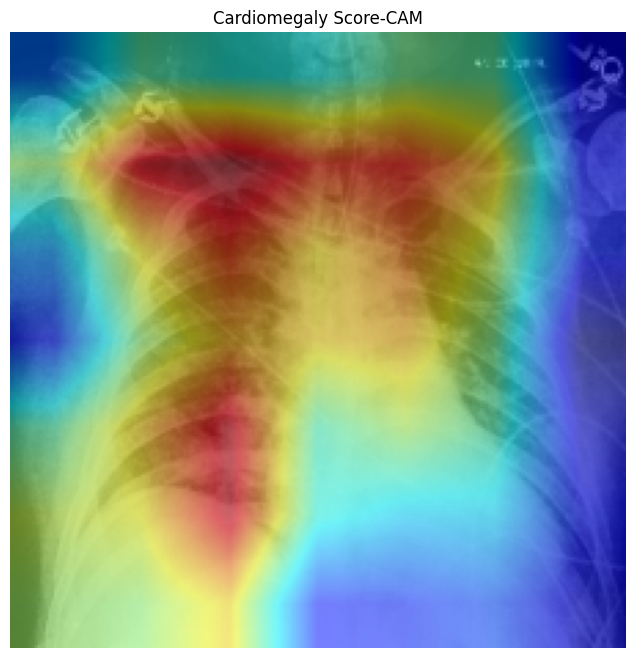

In [23]:
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam.utils.image import show_cam_on_image

images,labels=next(iter(val_loader))

input_tensor=images[0].unsqueeze(0).to(device)

rgb_image=images[0].permute(1,2,0).numpy()

rgb_image=(rgb_image-rgb_image.min())/(rgb_image.max()-rgb_image.min())

targets=[ClassifierOutputTarget(0)]

grayscale_cam=cam(
    input_tensor=input_tensor,
    targets=targets
)[0]

visualization=show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))
plt.imshow(visualization)
plt.axis("off")
plt.title("Cardiomegaly Score-CAM")
plt.show()

100%|██████████| 64/64 [00:03<00:00, 17.97it/s]


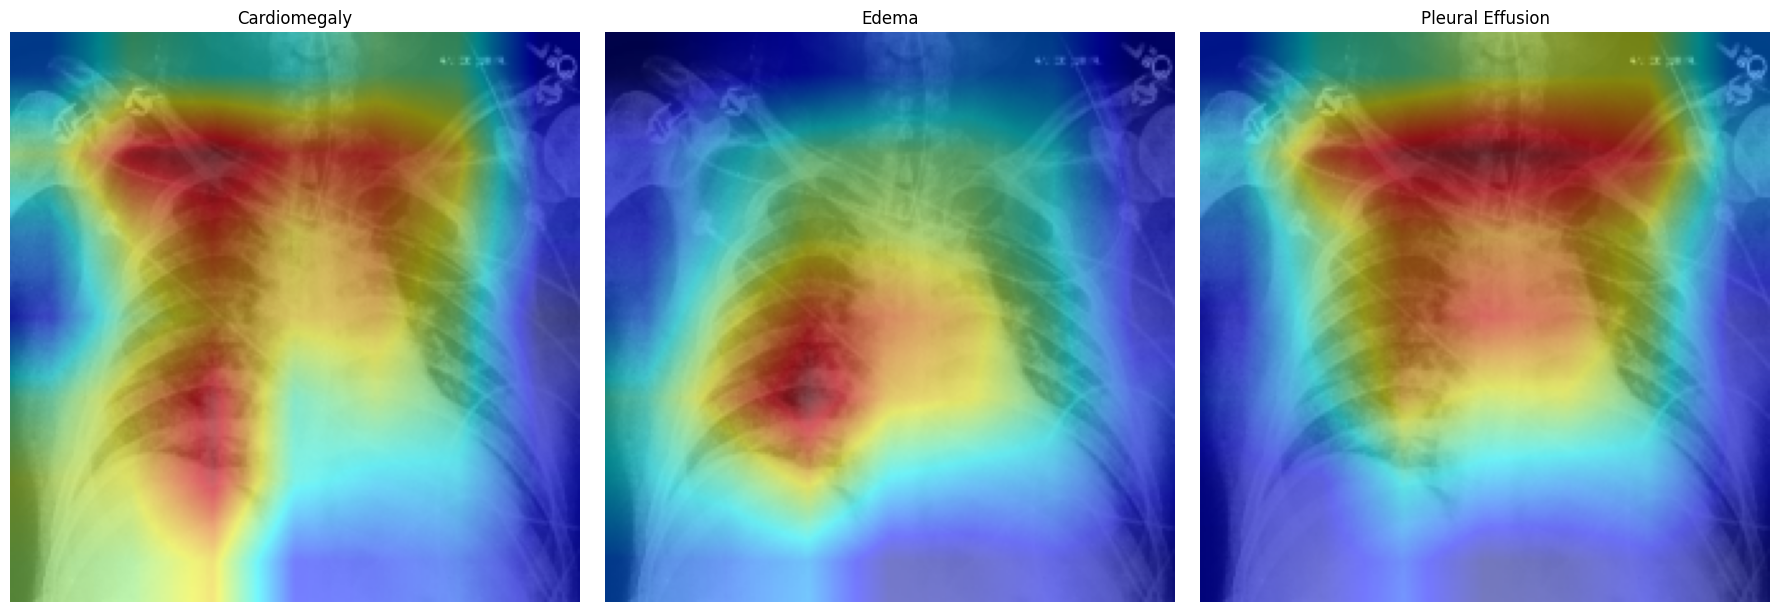

In [24]:
disease_names=[
    "Cardiomegaly",
    "Edema",
    "Pleural Effusion"
]

fig,axes=plt.subplots(1,3,figsize=(18,6))

for i,disease in enumerate(disease_names):

    targets=[ClassifierOutputTarget(i)]

    grayscale_cam=cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    visualization=show_cam_on_image(
        rgb_image,
        grayscale_cam,
        use_rgb=True
    )

    axes[i].imshow(visualization)
    axes[i].set_title(disease)
    axes[i].axis("off")

plt.tight_layout()

plt.savefig("all_disease_scorecam.png")

plt.show()

In [25]:
import matplotlib.pyplot as plt
plt.savefig(f"{disease}_scorecam.png")

<Figure size 640x480 with 0 Axes>

In [26]:
# HYBRID CNN - TRANSFORMER TECHNIQUE

In [27]:
# HYBRID CNN - TRANSFORMER TECHNIQUE

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class HybridCNNTransformer(nn.Module):
    def __init__(self, num_classes, num_layers=2, nhead=8, dim_feedforward=2048):
        super().__init__()

        # CNN backbone: reuse DenseNet121's conv layers only (no classifier)
        densenet = models.densenet121(weights="DEFAULT")
        self.cnn_backbone = densenet.features  # outputs (B, 1024, 7, 7)
        self.feature_dim = 1024

        # learnable [CLS] token, same idea as ViT/BERT - summarizes the whole image
        self.cls_token = nn.Parameter(torch.zeros(1, 1, self.feature_dim))

        # positional embeddings so transformer knows patch order (49 patches + 1 cls = 50)
        self.pos_embed = nn.Parameter(torch.zeros(1, 50, self.feature_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.feature_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Linear(self.feature_dim, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        feat_map = self.cnn_backbone(x)          # (B, 1024, 7, 7)
        feat_map = F.relu(feat_map)               # DenseNet convention before pooling

        B, C, H, W = feat_map.shape
        tokens = feat_map.flatten(2).transpose(1, 2)   # (B, 49, 1024) - each patch is a "token"

        cls_tokens = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls_tokens, tokens], dim=1)  # (B, 50, 1024)
        tokens = tokens + self.pos_embed

        encoded = self.transformer(tokens)
        cls_out = encoded[:, 0]                    # take the CLS token's final representation

        return self.classifier(cls_out)

In [28]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)          # confidence in the correct answer
        focal_weight = (1 - pt) ** self.gamma                        # down-weights easy examples
        alpha_weight = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha_weight * focal_weight * bce).mean()

In [29]:
DISEASES = ["Cardiomegaly", "Edema", "Pleural Effusion"]

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_hybrid = HybridCNNTransformer(num_classes=len(DISEASES)).to(device)

criterion_hybrid = FocalLoss(alpha=0.25, gamma=2.0)

optimizer_hybrid = torch.optim.Adam(model_hybrid.parameters(), lr=1e-4)

# reduces LR automatically if val loss stalls - addresses overfitting
scheduler_hybrid = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_hybrid, mode="min", factor=0.5, patience=2
)

print(model_hybrid)

HybridCNNTransformer(
  (cnn_backbone): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

In [31]:
num_epochs = 20
best_val_loss = float("inf")
patience = 4
counter = 0

for epoch in range(num_epochs):

    model_hybrid.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_hybrid.zero_grad()
        outputs = model_hybrid(images)
        loss = criterion_hybrid(outputs, labels)
        loss.backward()
        optimizer_hybrid.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    model_hybrid.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_hybrid(images)
            loss = criterion_hybrid(outputs, labels)
            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)
    scheduler_hybrid.step(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_hybrid.state_dict(), "best_hybrid_model.pth")
        print("Best model saved")
        counter = 0
    else:
        counter += 1
        print(f"No improvement count: {counter}")
        if counter >= patience:
            print("Early stopping triggered")
            break

Epoch [1/20] Train Loss: 0.0805 Val Loss: 0.0696
Best model saved
Epoch [2/20] Train Loss: 0.0632 Val Loss: 0.0745
No improvement count: 1
Epoch [3/20] Train Loss: 0.0571 Val Loss: 0.0683
Best model saved
Epoch [4/20] Train Loss: 0.0498 Val Loss: 0.0809
No improvement count: 1
Epoch [5/20] Train Loss: 0.0425 Val Loss: 0.0857
No improvement count: 2
Epoch [6/20] Train Loss: 0.0353 Val Loss: 0.0954
No improvement count: 3
Epoch [7/20] Train Loss: 0.0220 Val Loss: 0.1204
No improvement count: 4
Early stopping triggered


In [32]:
from sklearn.metrics import f1_score, roc_auc_score
import numpy as np

model_hybrid.load_state_dict(torch.load("best_hybrid_model.pth"))
model_hybrid.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_hybrid(images)
        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs > 0.5).astype(int)

hybrid_f1, hybrid_auc = [], []

for i, disease in enumerate(DISEASES):
    f1 = f1_score(all_labels[:, i], all_preds[:, i])
    auc = roc_auc_score(all_labels[:, i], all_probs[:, i])
    hybrid_f1.append(f1)
    hybrid_auc.append(auc)
    print(disease, "F1:", round(f1, 4), "| AUC:", round(auc, 4))

Cardiomegaly F1: 0.3693 | AUC: 0.6731
Edema F1: 0.1689 | AUC: 0.7062
Pleural Effusion F1: 0.7345 | AUC: 0.7772


In [33]:
from sklearn.metrics import precision_recall_curve

best_thresholds = []
tuned_f1 = []

for i, disease in enumerate(DISEASES):
    precisions, recalls, thresholds = precision_recall_curve(all_labels[:, i], all_probs[:, i])

    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = f1_scores.argmax()

    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_thresholds.append(best_thresh)
    tuned_f1.append(f1_scores[best_idx])

    print(f"{disease}: best threshold = {best_thresh:.3f}, tuned F1 = {f1_scores[best_idx]:.4f}")

Cardiomegaly: best threshold = 0.293, tuned F1 = 0.6366
Edema: best threshold = 0.250, tuned F1 = 0.7426
Pleural Effusion: best threshold = 0.322, tuned F1 = 0.8341


100%|██████████| 64/64 [00:04<00:00, 15.43it/s]


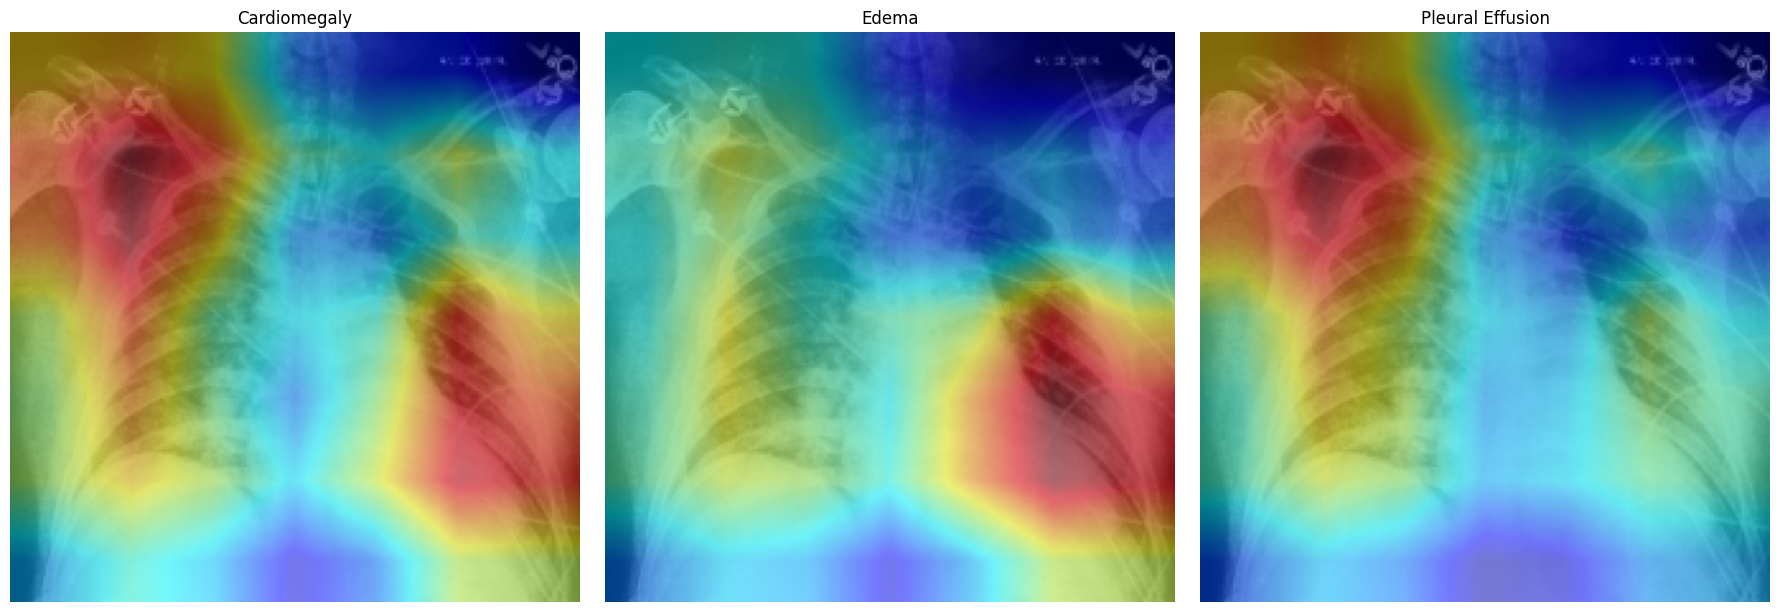

In [34]:
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt

target_layer_hybrid = model_hybrid.cnn_backbone[-1]

cam_hybrid = ScoreCAM(model=model_hybrid, target_layers=[target_layer_hybrid])

images, labels = next(iter(val_loader))
input_tensor = images[0].unsqueeze(0).to(device)
rgb_image = images[0].permute(1, 2, 0).numpy()
rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, disease in enumerate(DISEASES):
    targets = [ClassifierOutputTarget(i)]
    grayscale_cam = cam_hybrid(input_tensor=input_tensor, targets=targets)[0]
    visualization = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)
    axes[i].imshow(visualization)
    axes[i].set_title(disease)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

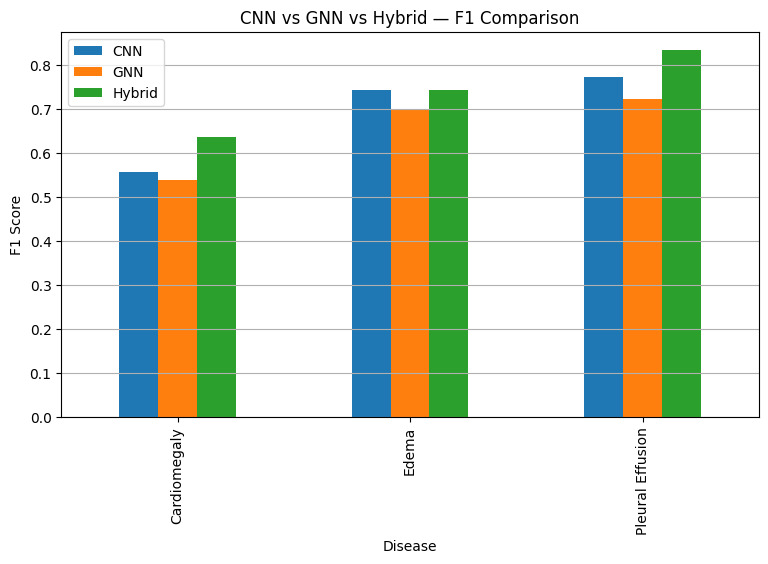

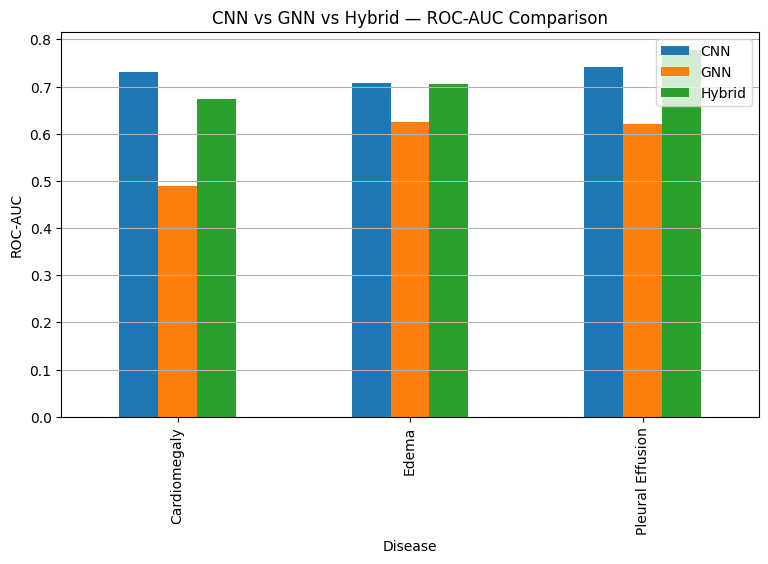

In [35]:
import pandas as pd

comparison_f1 = pd.DataFrame({
    "Disease": DISEASES,
    "CNN": [0.5573, 0.7432, 0.7733],
    "GNN": [0.5390, 0.7005, 0.7220],
    "Hybrid": tuned_f1
})

comparison_f1.plot(x="Disease", y=["CNN", "GNN", "Hybrid"], kind="bar", figsize=(9, 5))
plt.ylabel("F1 Score")
plt.title("CNN vs GNN vs Hybrid — F1 Comparison")
plt.grid(axis="y")
plt.show()

comparison_auc = pd.DataFrame({
    "Disease": DISEASES,
    "CNN": [0.7299, 0.7072, 0.7423],
    "GNN": [0.4903, 0.6242, 0.6204],
    "Hybrid": hybrid_auc
})

comparison_auc.plot(x="Disease", y=["CNN", "GNN", "Hybrid"], kind="bar", figsize=(9, 5))
plt.ylabel("ROC-AUC")
plt.title("CNN vs GNN vs Hybrid — ROC-AUC Comparison")
plt.grid(axis="y")
plt.show()